In [2]:
import sys
print(f"Python version: {sys.version}")
assert sys.version_info >= (3, 8), "Please upgrade to Python 3.8+"
print("✅ Python version OK")

Python version: 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
✅ Python version OK


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import shutil
import random

print("✅ TensorFlow:", tf.__version__)
print("✅ NumPy:", np.__version__)
print("✅ OpenCV:", cv2.__version__)
print("✅ All libraries imported successfully!")

2026-03-29 19:21:25.285246: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ TensorFlow: 2.16.2
✅ NumPy: 1.26.4
✅ OpenCV: 4.11.0
✅ All libraries imported successfully!


In [4]:
# Verify folder structure exists
folders = ["data/raw", "data/train", "data/val", "model", "app"]

for folder in folders:
    if os.path.exists(folder):
        print(f"✅ {folder}")
    else:
        print(f"❌ {folder} — missing! Run mkdir to create it")

✅ data/raw
✅ data/train
✅ data/val
✅ model
✅ app


In [5]:
# Map Kaggle's 6 categories to our 4 waste classes
CATEGORY_MAP = {
    "cardboard": "recyclable",
    "paper":     "recyclable",
    "metal":     "recyclable",
    "glass":     "recyclable",
    "plastic":   "recyclable",
    "trash":     "landfill",
}

RAW_DIR   = "data/raw/Garbage classification"
VAL_SPLIT = 0.2

for kaggle_cat, our_class in CATEGORY_MAP.items():
    src_folder = os.path.join(RAW_DIR, kaggle_cat)
    if not os.path.exists(src_folder):
        print(f"⚠️  Skipping '{kaggle_cat}' — folder not found")
        continue

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(images)
    split = int(len(images) * (1 - VAL_SPLIT))

    for split_name, file_list in [("train", images[:split]), ("val", images[split:])]:
        dest = os.path.join("data", split_name, our_class)
        os.makedirs(dest, exist_ok=True)
        for f in file_list:
            shutil.copy(os.path.join(src_folder, f), os.path.join(dest, f))
    
    print(f"✅ Sorted '{kaggle_cat}' → {our_class}")

print("\n🎉 Sorting complete!")

✅ Sorted 'cardboard' → recyclable
✅ Sorted 'paper' → recyclable
✅ Sorted 'metal' → recyclable
✅ Sorted 'glass' → recyclable
✅ Sorted 'plastic' → recyclable
✅ Sorted 'trash' → landfill

🎉 Sorting complete!


In [7]:
# Check image counts per folder
for split in ["train", "val"]:
    print(f"\n📁 data/{split}/")
    for cls in sorted(os.listdir(f"data/{split}")):
        path = f"data/{split}/{cls}"
        if os.path.isdir(path):  # skip .gitkeep
            count = len(os.listdir(path))
            print(f"   {cls}: {count} images")


📁 data/train/
   landfill: 109 images
   recyclable: 1910 images

📁 data/val/
   landfill: 28 images
   recyclable: 480 images


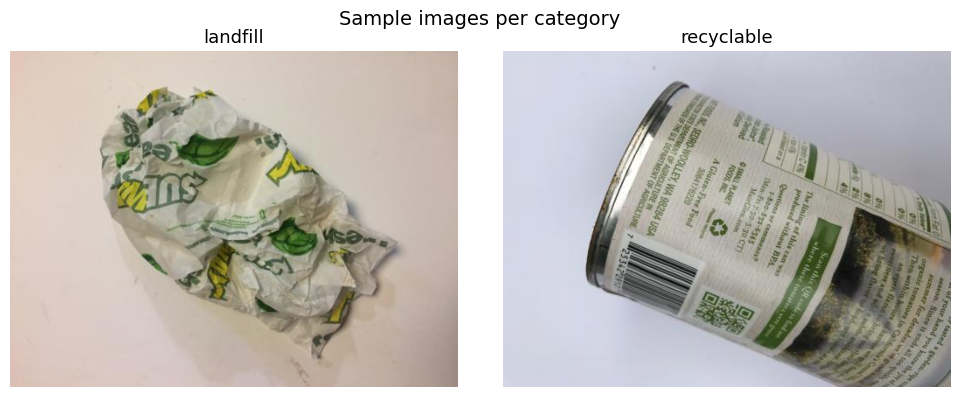

In [8]:
# Preview one sample image per category
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
classes = sorted([c for c in os.listdir("data/train") if os.path.isdir(f"data/train/{c}")])

for ax, cls in zip(axes, classes):
    folder = f"data/train/{cls}"
    sample = os.path.join(folder, os.listdir(folder)[0])
    img = plt.imread(sample)
    ax.imshow(img)
    ax.set_title(cls, fontsize=13)
    ax.axis("off")

plt.suptitle("Sample images per category", fontsize=14)
plt.tight_layout()
plt.show()